<a href="https://colab.research.google.com/github/danielsovres/Aulas/blob/main/ML%20(final%20do%20m%C3%B3dulo)%20-%20Feature%20Engineering%20e%20Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""
Comentários pós aula
O Pipeline deve ser aplicado fazendo uma lista com tuplas para cada função que queremos aplicar

Primeiro eu crio o pipe_features_num (com a lista de tuplas contendo os processamentos desejados)
Depois eu crio o features_num, que vai servir pra diferenciar o que é numérico do que é categórico
Logo depois eu crio pipe_features_cat e features_cat (excluindo = np.number)

OneHotEncoder() transforma os dados categóricos em números que a máquina consegue entender

O pre-processador será um ColumnTransformer com o transf_num e transf_cat
O ColumnTransformer seleciona o que for numérico e aplica no numérico e o que for categórico e aplica no categórico

O pipeline final será o pre-processamento (que é o ColumnTransformer) e o RandomForest
Dessa forma, conseguimos juntar todas as etapas em um único objeto Pipeline

Se for encontrado um cenário de overfitting, podemos utilizar o GridSearchCV,
para encontrar uma combinação de hiperparâmetros com boa performance.
Só que dessa vez, nosso estimator será o pipe_rf

Se o overfitting permanece, podemos testar outros hiperparâmetros,
Utilizar outro scoring no GridSearchCV (outro critério de teste de hiperparâmetros)
"""



# Aula 10 - Feature Engineering e Pipeline

Quando lidamos com modelagem em Machine Learning, é extremamente usual nos depararmos com situações que requerem processamento de dados para correta interpretabilidade dos resultados, bem como para satisfazer adequadamente as hipóteses que norteiam diversos dos modelos que podemos utilizar.

Neste sentido, o scikit learn nos traz algumas ferramentas muito úteis que podem auxiliar a padronizar e facilitar o trabalho de ingestão e processamento de dados. É este o foco desta nossa aula!

___

### Pipeline

Sempre que executarmos as etapas do ciclo de modelagem em Machine Learning, podemos definir uma sequência de passos gerais de processamento de dados, que poderá ser particularizada a cada problema. Por exemplo: podemos querer testar vários tipos de modelos diferentes, mas aplicando o mesmo passo a passo de pré-processamento. Assim, podemos "encapsular" o passo a passo que queremos aplicá-lo a cada modelo com os [**pipelines**](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) do scikit-learn.

O Pipeline é uma estratégia, que o sklearn proporciona, a fim de garantir que possamos, em uma única estrutura, passar **o estimador e o transformador** (e muitas outras ferramentas!). Para maiores informações, [clique aqui](https://scikit-learn.org/stable/modules/compose.html#pipeline).

Vamos ver a seguir como esta estrutura funciona:

In [ ]:
from sklearn.pipeline import Pipeline # import do pipeline

Para definir o Pipeline, podemos estruturar uma lista de etapas referentes ao processamento de dados.

Vamos, por exemplo, dizer que queiramos aplicar uma normalização nos dados com o StandardScaler, e utilizar o estimador "RandomForestClassifier", ainda pensando no problema de predição de risco de crédito,

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# definição da lista de etapas do Pipeline
lista_etapas = [("std_scaler", StandardScaler()), ("rf", RandomForestClassifier())]

In [ ]:
""" O Pipeline deve ser aplicado fazendo uma lista com tuplas para cada função que queremos aplicar


In [ ]:
lista_etapas

[('std_scaler', StandardScaler()), ('rf', RandomForestClassifier())]

In [ ]:
# Criação do pipeline
pipe = Pipeline(lista_etapas)

In [ ]:
pipe

Pipeline(steps=[('std_scaler', StandardScaler()),
                ('rf', RandomForestClassifier())])

Vemos, acima, de maneira ilustrativa, que o *Pipeline* que definimos possui duas grandes etapas: um processamento de dados definido pela estrutura **StandardScaler**, e um estimador que será utilizado nos dados resultantes deste processamento, o **RandomForestClassifier**.

Na sequência, vamos ler nossa base de dados e aplicar os passos do Ciclo de Modelagem para treinar o modelo de classificação, mas, agora utilizando o Pipeline!

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import KFold, GridSearchCV, train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [ ]:
df = pd.read_csv("datasets/german_credit_data.csv", index_col = 0)

X = df.drop(columns = "Risk")
y = df["Risk"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)

Vamos fazer Pipelines para tratar as features numéricas e categóricas:

In [ ]:
# TRATAMENTO DE FEATURES NUMÉRICAS
etapas_tratamento_num = [("input_num", SimpleImputer(strategy = "mean")),
                        ("Normalização", StandardScaler())]
pipe_features_num = Pipeline(etapas_tratamento_num) #criação e instanciamento do pipeline

features_num = X_train.select_dtypes(include = np.number).columns.tolist() # selecionando apenas dados numéricos
pipe_features_num

Pipeline(steps=[('input_num', SimpleImputer()),
                ('Normalização', StandardScaler())])

In [ ]:
"""Primeiro eu crio o pipe_features_num (com a lista de tuplas contendo os processamentos desejados)
Depois eu crio o features_num, que vai servir pra diferenciar o que é numérico do que é categórico
Logo depois eu crio pipe_features_cat e features_cat (excluindo = np.number)

In [ ]:
# TRATAMENTO DE FEATURES CATEGÓRICAS
etapas_tratamento_cat = [("input_cat", SimpleImputer(strategy = "constant", fill_value = "unknown")), #já inclui as estratégias do SimpleImputer
                        ("onehot", OneHotEncoder())]
pipe_features_cat = Pipeline(etapas_tratamento_cat)
features_cat = X_train.select_dtypes(exclude = np.number).columns.tolist() # selecionando apenas colunas categóricas
pipe_features_cat

Pipeline(steps=[('input_cat',
                 SimpleImputer(fill_value='unknown', strategy='constant')),
                ('onehot', OneHotEncoder())])

In [ ]:
"""OneHotEncoder() transforma os dados categóricos em números que a máquina consegue entender"""

In [ ]:
pre_processador = ColumnTransformer([("transf_num", pipe_features_num, features_num),
                                    ("transf_cat", pipe_features_cat, features_cat)])
#crio o pre_processador

In [ ]:
"""
O pre-processador será um ColumnTransformer com o transf_num e transf_cat
O ColumnTransformer seleciona o que for numérico e aplica no numérico e o que for categórico e aplica no categórico"""

In [ ]:
# pipeline final
pipe_rf = Pipeline([("pre_processamento", pre_processador),
                   ("RandomForest", RandomForestClassifier(random_state = 42))])

In [ ]:
pipe_rf

Pipeline(steps=[('pre_processamento',
                 ColumnTransformer(transformers=[('transf_num',
                                                  Pipeline(steps=[('input_num',
                                                                   SimpleImputer()),
                                                                  ('Normalização',
                                                                   StandardScaler())]),
                                                  ['Age', 'Job',
                                                   'Credit amount',
                                                   'Duration']),
                                                 ('transf_cat',
                                                  Pipeline(steps=[('input_cat',
                                                                   SimpleImputer(fill_value='unknown',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder())]),
                                                  ['Sex', 'Housing',
                                                   'Saving accounts',
                                                   'Checking account',
                                                   'Purpose'])])),
                ('RandomForest', RandomForestClassifier(random_state=42))])

In [ ]:
"""O pipeline final será o pre-processamento (que é o ColumnTransformer) e o RandomForest
Dessa forma, conseguimos juntar todas as etapas em um único objeto Pipeline
"""

Vemos, assim, como conseguimos condensar todas as etapas do nosso pré-processamento em um único objeto do tipo Pipeline ("pipe_rf"):

- para as features numéricas, utilizamos o SimpleImputer para preencher dados faltantes com a média da coluna;
- para as features categóricas, utilizamos o SimpleImputer para preencher com "unknow" os valores faltantes;
- após o processamento, todos os dados, já com as devidas transformações, serão utilizados como endrada no treinamento e teste do classificador Random Forest.

In [ ]:
pipe_rf.fit(X_train, y_train) #fit do treino

Pipeline(steps=[('pre_processamento',
                 ColumnTransformer(transformers=[('transf_num',
                                                  Pipeline(steps=[('input_num',
                                                                   SimpleImputer()),
                                                                  ('Normalização',
                                                                   StandardScaler())]),
                                                  ['Age', 'Job',
                                                   'Credit amount',
                                                   'Duration']),
                                                 ('transf_cat',
                                                  Pipeline(steps=[('input_cat',
                                                                   SimpleImputer(fill_value='unknown',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder())]),
                                                  ['Sex', 'Housing',
                                                   'Saving accounts',
                                                   'Checking account',
                                                   'Purpose'])])),
                ('RandomForest', RandomForestClassifier(random_state=42))])

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

==== Avaliação no conjunto de treinamento ====


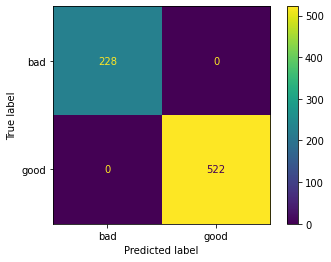

              precision    recall  f1-score   support

         bad       1.00      1.00      1.00       228
        good       1.00      1.00      1.00       522

    accuracy                           1.00       750
   macro avg       1.00      1.00      1.00       750
weighted avg       1.00      1.00      1.00       750


==== Avaliação no conjunto de teste ====


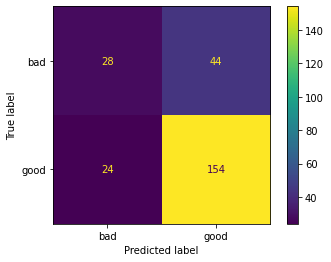

              precision    recall  f1-score   support

         bad       0.54      0.39      0.45        72
        good       0.78      0.87      0.82       178

    accuracy                           0.73       250
   macro avg       0.66      0.63      0.64       250
weighted avg       0.71      0.73      0.71       250



In [ ]:
# Avaliação no conjunto de treinamento
print("==== Avaliação no conjunto de treinamento ====")
y_pred_train = pipe_rf.predict(X_train)
ConfusionMatrixDisplay.from_predictions(y_train, y_pred_train)
plt.show()
print(classification_report(y_train, y_pred_train))

print("\n==== Avaliação no conjunto de teste ====")
y_pred_test = pipe_rf.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test)
plt.show()
print(classification_report(y_test, y_pred_test))

Vimos, assim, como realizar a aplicação do Pipeline! Vale ressaltar que nos encontramos, ao fim de tudo, em um cenário de overfitting. Poderíamos acrescentar o GridSearchCV ao Pipeline, para tentar encontrar uma combinação de hiperparâmetros com boa performance e que nos permita escapar deste cenário! A diferença, agora, é que o "pipe_rf" será o nosso estimador para o Grid!

In [ ]:
"""Se for encontrado um cenário de overfitting, podemos utilizar o GridSearchCV,
para encontrar uma combinação de hiperparâmetros com boa performance.
Só que dessa vez, nosso estimator será o pipe_rf
"""

In [ ]:
params_grid = {"RandomForest__n_estimators": [100, 300, 500]}

grid_rf = GridSearchCV(estimator = pipe_rf,
                      param_grid = params_grid,
                      scoring = 'f1_weighted',
                      verbose=10)
grid_rf.fit(X_train, y_train)

Fitting 5 folds for each of 3 candidates, totalling 15 fits
[CV 1/5; 1/3] START RandomForest__n_estimators=100..............................
[CV 1/5; 1/3] END RandomForest__n_estimators=100;, score=0.724 total time=   0.2s
[CV 2/5; 1/3] START RandomForest__n_estimators=100..............................
[CV 2/5; 1/3] END RandomForest__n_estimators=100;, score=0.651 total time=   0.2s
[CV 3/5; 1/3] START RandomForest__n_estimators=100..............................
[CV 3/5; 1/3] END RandomForest__n_estimators=100;, score=0.712 total time=   0.2s
[CV 4/5; 1/3] START RandomForest__n_estimators=100..............................
[CV 4/5; 1/3] END RandomForest__n_estimators=100;, score=0.740 total time=   0.2s
[CV 5/5; 1/3] START RandomForest__n_estimators=100..............................
[CV 5/5; 1/3] END RandomForest__n_estimators=100;, score=0.709 total time=   0.2s
[CV 1/5; 2/3] START RandomForest__n_estimators=300..............................
[CV 1/5; 2/3] END RandomForest__n_estimators

GridSearchCV(estimator=Pipeline(steps=[('pre_processamento',
                                        ColumnTransformer(transformers=[('transf_num',
                                                                         Pipeline(steps=[('input_num',
                                                                                          SimpleImputer()),
                                                                                         ('Normalização',
                                                                                          StandardScaler())]),
                                                                         ['Age',
                                                                          'Job',
                                                                          'Credit '
                                                                          'amount',
                                                                          'Duration']),
                                                                        ('transf_cat',
                                                                         Pipeline(steps=[('input_cat',
                                                                                          SimpleImputer(fill_value='unknown',
                                                                                                        strategy='constant')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder())]),
                                                                         ['Sex',
                                                                          'Housing',
                                                                          'Saving '
                                                                          'accounts',
                                                                          'Checking '
                                                                          'account',
                                                                          'Purpose'])])),
                                       ('RandomForest',
                                        RandomForestClassifier(random_state=42))]),
             param_grid={'RandomForest__n_estimators': [100, 300, 500]},
             scoring='f1_weighted', verbose=10)

In [ ]:
grid_rf.best_params_

{'RandomForest__n_estimators': 300}

In [ ]:
grid_rf.best_score_

0.7124167726612793

==== Avaliação no conjunto de treinamento ====


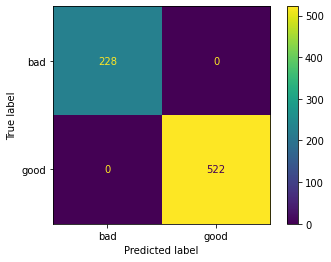

              precision    recall  f1-score   support

         bad       1.00      1.00      1.00       228
        good       1.00      1.00      1.00       522

    accuracy                           1.00       750
   macro avg       1.00      1.00      1.00       750
weighted avg       1.00      1.00      1.00       750


==== Avaliação no conjunto de teste ====


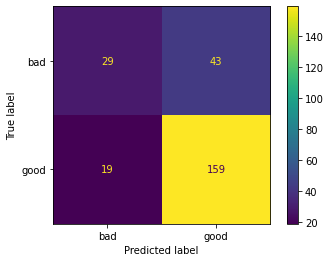

              precision    recall  f1-score   support

         bad       0.60      0.40      0.48        72
        good       0.79      0.89      0.84       178

    accuracy                           0.75       250
   macro avg       0.70      0.65      0.66       250
weighted avg       0.73      0.75      0.74       250



In [ ]:
# Avaliação no conjunto de treinamento
print("==== Avaliação no conjunto de treinamento ====")
y_pred_train = grid_rf.predict(X_train)
ConfusionMatrixDisplay.from_predictions(y_train, y_pred_train)
plt.show()
print(classification_report(y_train, y_pred_train))

print("\n==== Avaliação no conjunto de teste ====")
y_pred_test = grid_rf.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test)
plt.show()
print(classification_report(y_test, y_pred_test))

Mas parece que continuamos com Overfitting! Como poderíamos sair dessa situação?

In [ ]:
"""Se o overfitting permanece, podemos testar outros hiperparâmetros,
Utilizar outro scoring no GridSearchCV (outro critério de teste de hiperparâmetros)
"""